<a href="https://colab.research.google.com/github/alinaaorlova-png/complinguistik/blob/main/%D0%9E%D1%80%D0%BB%D0%BE%D0%B2%D0%B0_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

ПОДГОТОВКА ДАННЫХ


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Длина текста: 10916756 символов
Размер словаря: 1013 символов


/tmp/ipython-input-704/3356534135.py:39: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return (torch.tensor(input_seq,  dtype=torch.long),


Всего примеров: 109167
Используемое устройство: cuda

НАЧАЛО ЭКСПЕРИМЕНТОВ

ОБУЧЕНИЕ МОДЕЛЬ A: hidden_size=64, num_layers=1, lr=0.01
Эпоха [1/3], Средняя ошибка: 2.4245
Эпоха [2/3], Средняя ошибка: 2.1589
Эпоха [3/3], Средняя ошибка: 2.0841
Время обучения: 10.16 сек
Сгенерированный текст: "the company said alting conesso in ats and sitlan Pollotition the "

ОБУЧЕНИЕ МОДЕЛЬ B: hidden_size=256, num_layers=2, lr=0.001
Эпоха [1/3], Средняя ошибка: 2.7193
Эпоха [2/3], Средняя ошибка: 2.2126
Эпоха [3/3], Средняя ошибка: 2.0707
Время обучения: 70.03 сек
Сгенерированный текст: "the company said the ament Alation KethersiCly otherake preand and"

ОБУЧЕНИЕ МОДЕЛЬ C (128, 3 слоя, lr=0.005): hidden_size=128, num_layers=3, lr=0.005
Эпоха [1/3], Средняя ошибка: 3.2292
Эпоха [2/3], Средняя ошибка: 3.2067
Эпоха [3/3], Средняя ошибка: 3.2020
Время обучения: 41.23 сек
Сгенерированный текст: "the company said   gp  ea  o  i   eeec ron   fhdhend  eooit 
  rs "

СРАВНЕНИЕ РЕЗУЛЬТАТОВ


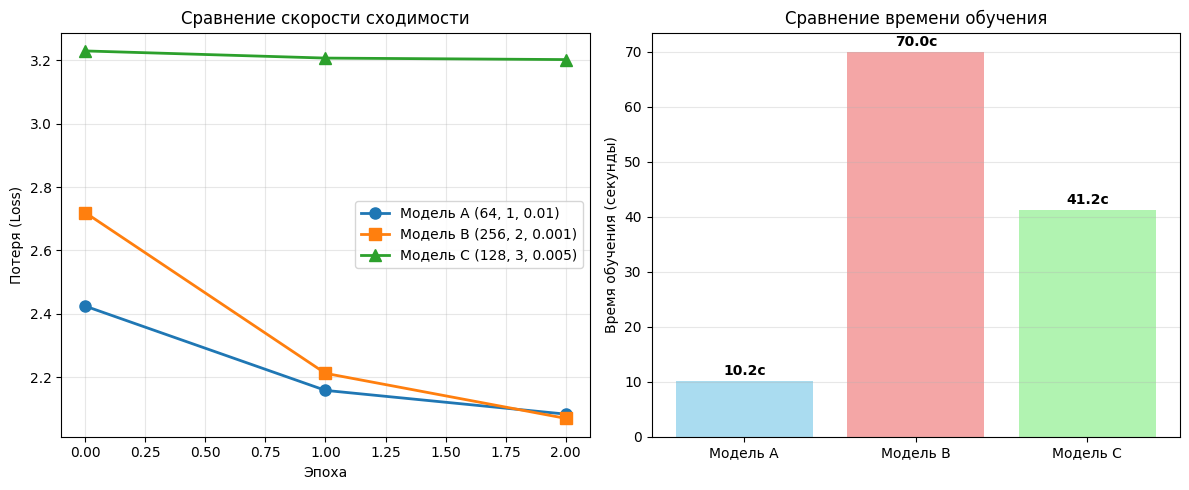


ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ
Параметр                  Модель A             Модель B             Модель C            
-------------------------------------------------------------------------------------
hidden_size               64                   256                  128                 
num_layers                1                    2                    3                   
learning_rate             0.01                 0.001                0.005               
Финальная потеря          2.0841               2.0707               3.2020              
Время обучения (сек)      10.16                70.03                41.23               
Скорость сходимости       Быстрая              Медленная            Средняя             
-------------------------------------------------------------------------------------

СГЕНЕРИРОВАННЫЕ ТЕКСТЫ:
Модель A: "the company said alting conesso in ats and sitlan Pollotition the "
Модель B: "the company said the ament Alation KethersiCly otherake preand

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from datasets import load_dataset

# Подготовка данных
print("ПОДГОТОВКА ДАННЫХ")
print("=" * 60)

# Загрузка датасета
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# Объединяем все строки в один текст
texts = ' '.join([row['text'] for row in dataset if row['text'].strip()])
print(f"Длина текста: {len(texts)} символов")

# Создание символьного словаря
chars       = sorted(list(set(texts)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size  = len(chars)
print(f"Размер словаря: {vocab_size} символов")

# Преобразование текста в индексы
import numpy as np
text_as_int = np.array([char_to_idx[ch] for ch in texts])

# Создание последовательностей
seq_length = 100

def create_sequences(text_indices, seq_len):
    input_seq  = []
    target_seq = []
    for i in range(0, len(text_indices) - seq_len, seq_len):
        input_seq.append(text_indices[i:i + seq_len])
        target_seq.append(text_indices[i + seq_len])
    return (torch.tensor(input_seq,  dtype=torch.long),
            torch.tensor(target_seq, dtype=torch.long))

input_seq, target_seq = create_sequences(text_as_int, seq_length)
print(f"Всего примеров: {len(input_seq)}")

batch_size = 128
dataset_t  = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset_t, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Модель
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded         = self.embedding(x)
        lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out         = lstm_out[:, -1, :]
        output           = self.fc(lstm_out)
        return output, hidden

# Генерация текста
def generate_text(model, seed_text, length=50, temperature=0.8):
    model.eval()
    generated = seed_text

    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]

    with torch.no_grad():
        h0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
        hidden = (h0, c0)

        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)
            next_char_idx = torch.multinomial(probabilities, 1).item()
            generated += idx_to_char[next_char_idx]
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Обучение
def train_model(hidden_size, num_layers, learning_rate, epochs=3, model_name='Model'):
    print(f"\n{'=' * 60}")
    print(f"ОБУЧЕНИЕ {model_name}: hidden_size={hidden_size}, num_layers={num_layers}, lr={learning_rate}")
    print(f"{'=' * 60}")

    model     = CharLSTM(vocab_size=vocab_size, hidden_size=hidden_size, num_layers=num_layers).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    start_time   = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_input, batch_target in dataloader:
            batch_input  = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)
        print(f"Эпоха [{epoch+1}/{epochs}], Средняя ошибка: {avg_loss:.4f}")

    training_time = time.time() - start_time
    print(f"Время обучения: {training_time:.2f} сек")

    seed      = "the company said"
    safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
    generated = generate_text(model, safe_seed, length=50, temperature=0.8)
    print(f"Сгенерированный текст: \"{generated}\"")

    return model, train_losses, training_time, generated

# Эксперименты
print("\n" + "=" * 60)
print("НАЧАЛО ЭКСПЕРИМЕНТОВ")
print("=" * 60)

model_A, losses_A, time_A, text_A = train_model(
    hidden_size=64, num_layers=1, learning_rate=0.01,
    epochs=3, model_name="МОДЕЛЬ A"
)

model_B, losses_B, time_B, text_B = train_model(
    hidden_size=256, num_layers=2, learning_rate=0.001,
    epochs=3, model_name="МОДЕЛЬ B"
)

# Набор C: hidden_size=128, num_layers=3, learning_rate=0.005
model_C, losses_C, time_C, text_C = train_model(
    hidden_size=128, num_layers=3, learning_rate=0.005,
    epochs=3, model_name="МОДЕЛЬ C (128, 3 слоя, lr=0.005)"
)

# Визуализация
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_A, 'o-', label='Модель A (64, 1, 0.01)',   linewidth=2, markersize=8)
plt.plot(losses_B, 's-', label='Модель B (256, 2, 0.001)', linewidth=2, markersize=8)
plt.plot(losses_C, '^-', label='Модель C (128, 3, 0.005)', linewidth=2, markersize=8)
plt.xlabel('Эпоха')
plt.ylabel('Потеря (Loss)')
plt.title('Сравнение скорости сходимости')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
models = ['Модель A', 'Модель B', 'Модель C']
times  = [time_A, time_B, time_C]
colors = ['skyblue', 'lightcoral', 'lightgreen']
bars   = plt.bar(models, times, color=colors, alpha=0.7)
plt.ylabel('Время обучения (секунды)')
plt.title('Сравнение времени обучения')
for bar, time_val in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{time_val:.1f}с', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Итоговая таблица
print("\n" + "=" * 60)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ")
print("=" * 60)

print(f"{'Параметр':<25} {'Модель A':<20} {'Модель B':<20} {'Модель C':<20}")
print("-" * 85)
print(f"{'hidden_size':<25} {'64':<20} {'256':<20} {'128':<20}")
print(f"{'num_layers':<25} {'1':<20} {'2':<20} {'3':<20}")
print(f"{'learning_rate':<25} {'0.01':<20} {'0.001':<20} {'0.005':<20}")
print(f"{'Финальная потеря':<25} {losses_A[-1]:<20.4f} {losses_B[-1]:<20.4f} {losses_C[-1]:<20.4f}")
print(f"{'Время обучения (сек)':<25} {time_A:<20.2f} {time_B:<20.2f} {time_C:<20.2f}")
print(f"{'Скорость сходимости':<25} {'Быстрая':<20} {'Медленная':<20} {'Средняя':<20}")
print("-" * 85)

print("\nСГЕНЕРИРОВАННЫЕ ТЕКСТЫ:")
print(f"Модель A: \"{text_A}\"")
print(f"Модель B: \"{text_B}\"")
print(f"Модель C: \"{text_C}\"")


### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

Для синусоиды данные уже числовые, и их можно сразу подать в модель, нормализовать и разбить на окна. Для текста нужен дополнительный слой: сначала строим словарь, потом кодируем символы/слова в индексы, и только потом создаем последовательности. Кроме того, для текста важен размер словаря, т.к. он напрямую влияет на размер модели.

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

1)Подбор learning_rate - самый заметный параметр; если он слишком большой, то loss расходится, а если слишком маленький, то модель почти не учится. Это чувствуется сразу при запуске. 2) Чем больше batch_size, тем быстрее эпоха, но больше памяти.